# Lab 3: PCA、聚类分析和差异表达分析

**作者**: 改编自R版本  
**日期**: 2024

---

## 概述 (Outline)

- PCA (主成分分析)
- K-Means聚类
- 层次聚类 (Hierarchical Clustering)
- 批次效应去除 (Batch Removal)
- DESeq2差异表达分析
- 基因富集分析 (GSEA)

## 安装和导入包

In [1]:
# 导入Python数据分析包
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 机器学习和统计
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

# 设置可视化样式
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']  # 支持中文显示

print("包导入成功！")

包导入成功！


## PCA (主成分分析)

### 什么是PCA?

- 找到变量的最佳线性组合
- "最佳"意味着描述最大方差的变量
- 可以产生数据的低维摘要
    - 将每个样本的100个数字总结为2个数字
- 对可视化等非常有用

### PCA分析示例

我们将使用sklearn内置的数据集进行演示。

In [2]:
# 加载示例数据 - 使用iris数据集作为演示
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# 创建DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['species'] = iris.target_names[y]

print("数据集前几行:")
print(df.head())
print(f"\n数据形状: {df.shape}")

数据集前几行:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

数据形状: (150, 5)


In [3]:
# 数据标准化 (PCA之前的重要步骤)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 执行PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 计算方差解释比例
explained_variance = pca.explained_variance_ratio_ * 100

print("各主成分解释的方差比例:")
for i, var in enumerate(explained_variance, 1):
    print(f"PC{i}: {var:.2f}%")

print(f"\n前两个主成分累计解释的方差: {sum(explained_variance[:2]):.2f}%")

各主成分解释的方差比例:
PC1: 72.96%
PC2: 22.85%
PC3: 3.67%
PC4: 0.52%

前两个主成分累计解释的方差: 95.81%


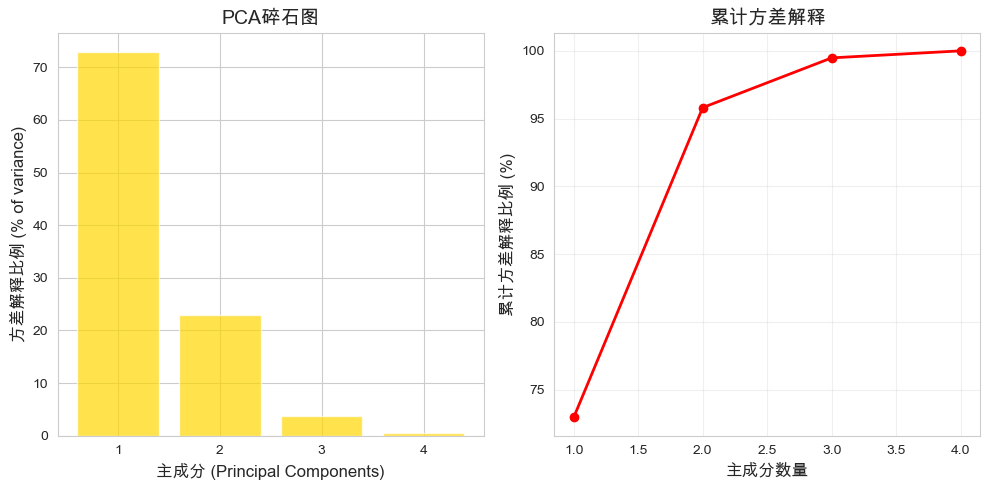

In [4]:
# 可视化方差解释比例
plt.figure(figsize=(10, 5))

# 碎石图 (Scree plot)
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7, color='gold')
plt.xlabel('主成分 (Principal Components)', fontsize=12)
plt.ylabel('方差解释比例 (% of variance)', fontsize=12)
plt.title('PCA碎石图', fontsize=14)
plt.xticks(range(1, len(explained_variance) + 1))

# 累计方差解释比例
plt.subplot(1, 2, 2)
plt.plot(range(1, len(explained_variance) + 1), 
         np.cumsum(explained_variance), 
         marker='o', color='red', linewidth=2)
plt.xlabel('主成分数量', fontsize=12)
plt.ylabel('累计方差解释比例 (%)', fontsize=12)
plt.title('累计方差解释', fontsize=14)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

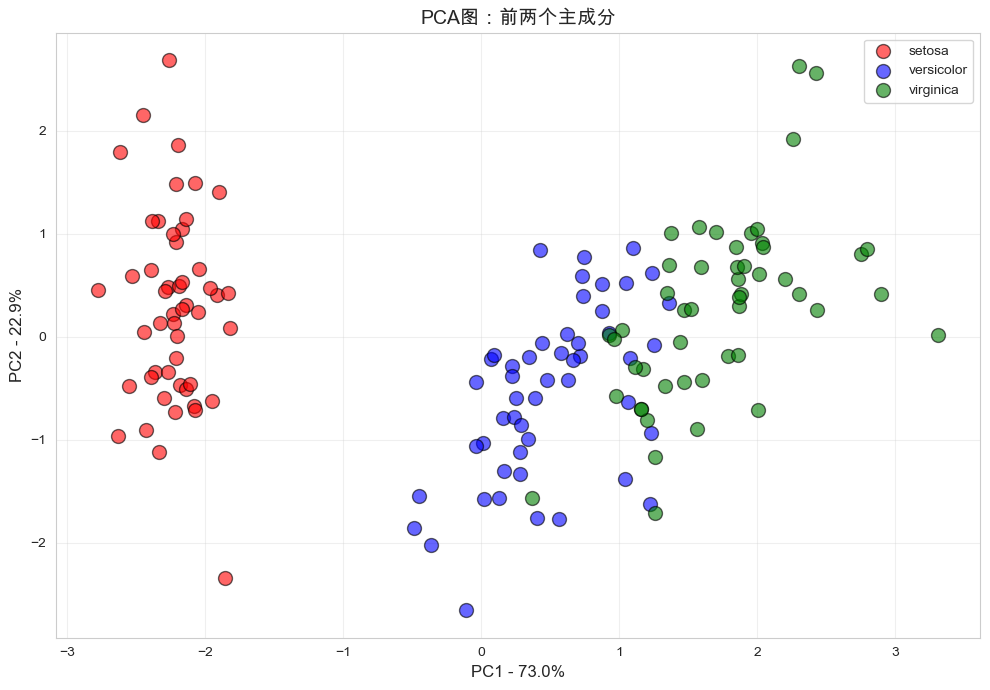

In [5]:
# PCA散点图 - 前两个主成分
plt.figure(figsize=(10, 7))

colors = ['red', 'blue', 'green']
for i, species in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[i], label=species, 
                alpha=0.6, edgecolors='k', s=100)

plt.xlabel(f'PC1 - {explained_variance[0]:.1f}%', fontsize=12)
plt.ylabel(f'PC2 - {explained_variance[1]:.1f}%', fontsize=12)
plt.title('PCA图：前两个主成分', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## K-Means聚类

### 什么是K-Means?

- 一种无监督方法，用于对数据进行聚类（不提供标签/结果）
- 需要预先指定聚类数量
- 可以使用所有基因，或仅使用差异表达的基因

### K-Means算法步骤:

1. 随机选择K个中心点
2. 将每个数据点分配给最近的中心
3. 重新计算每个簇的中心
4. 重复步骤2-3直到收敛

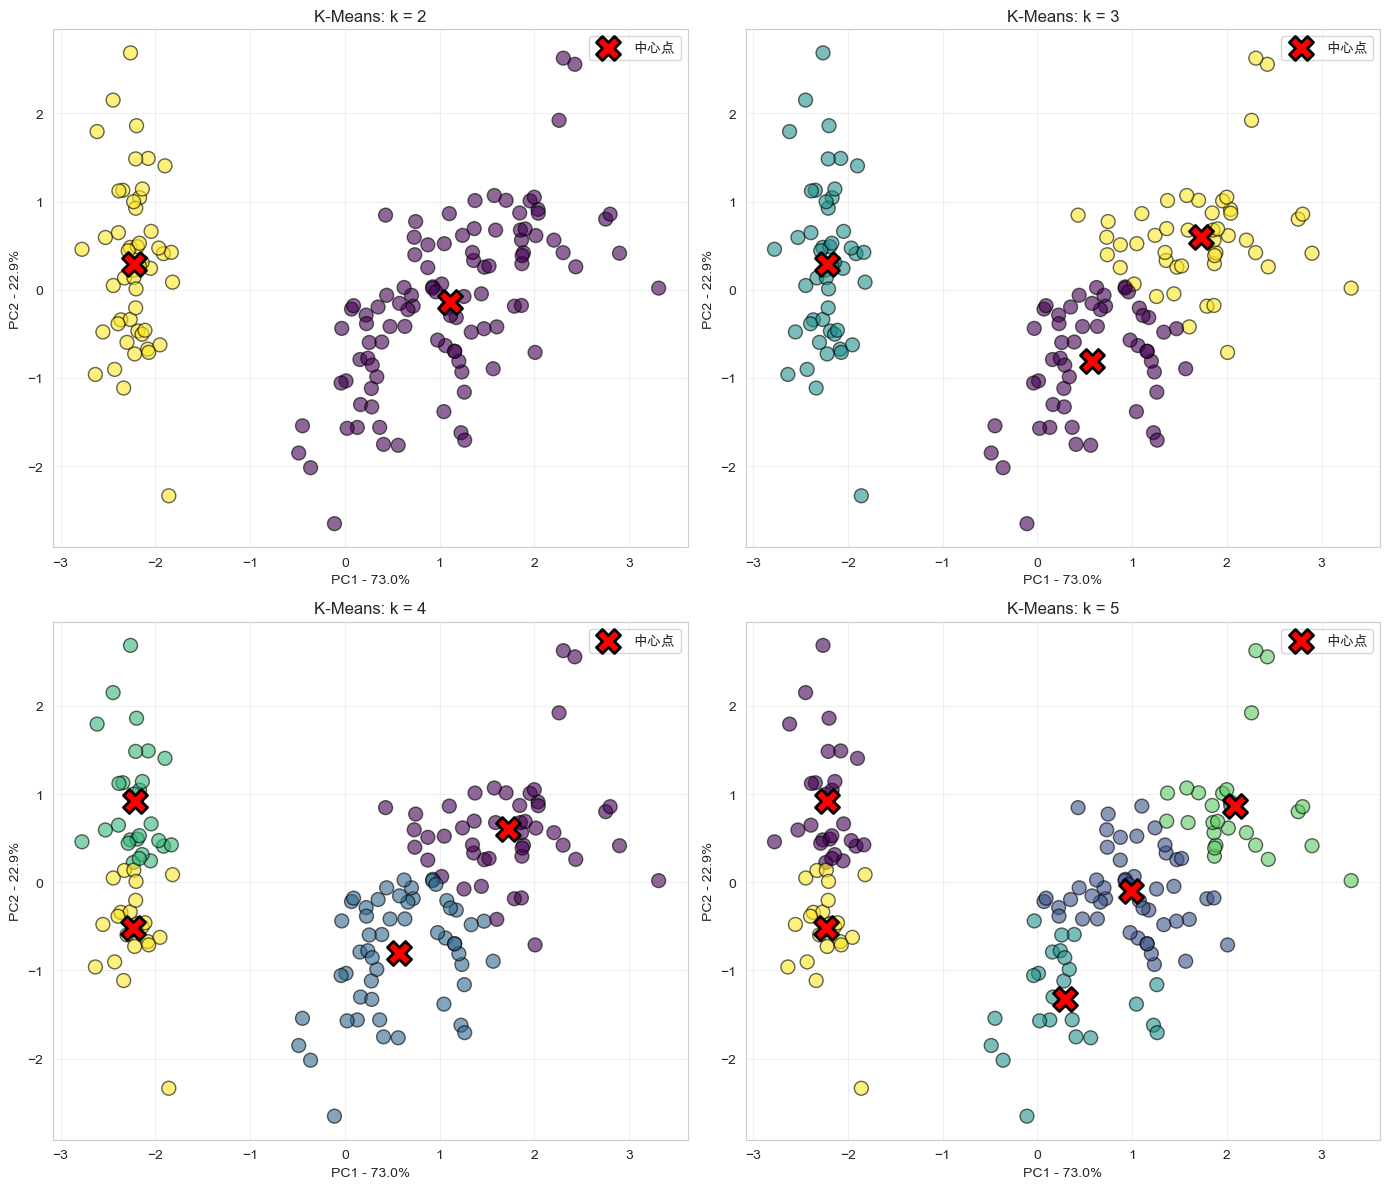

In [6]:
# 使用标准化后的数据进行K-Means聚类
# 尝试不同的K值
K_values = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, k in enumerate(K_values):
    # 执行K-Means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    
    # 绘制结果（使用PCA的前两个成分进行可视化）
    scatter = axes[idx].scatter(X_pca[:, 0], X_pca[:, 1], 
                                c=clusters, cmap='viridis', 
                                alpha=0.6, edgecolors='k', s=100)
    
    # 绘制聚类中心
    centers_pca = pca.transform(kmeans.cluster_centers_)
    axes[idx].scatter(centers_pca[:, 0], centers_pca[:, 1], 
                     c='red', marker='X', s=300, 
                     edgecolors='black', linewidths=2, label='中心点')
    
    axes[idx].set_xlabel(f'PC1 - {explained_variance[0]:.1f}%', fontsize=10)
    axes[idx].set_ylabel(f'PC2 - {explained_variance[1]:.1f}%', fontsize=10)
    axes[idx].set_title(f'K-Means: k = {k}', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

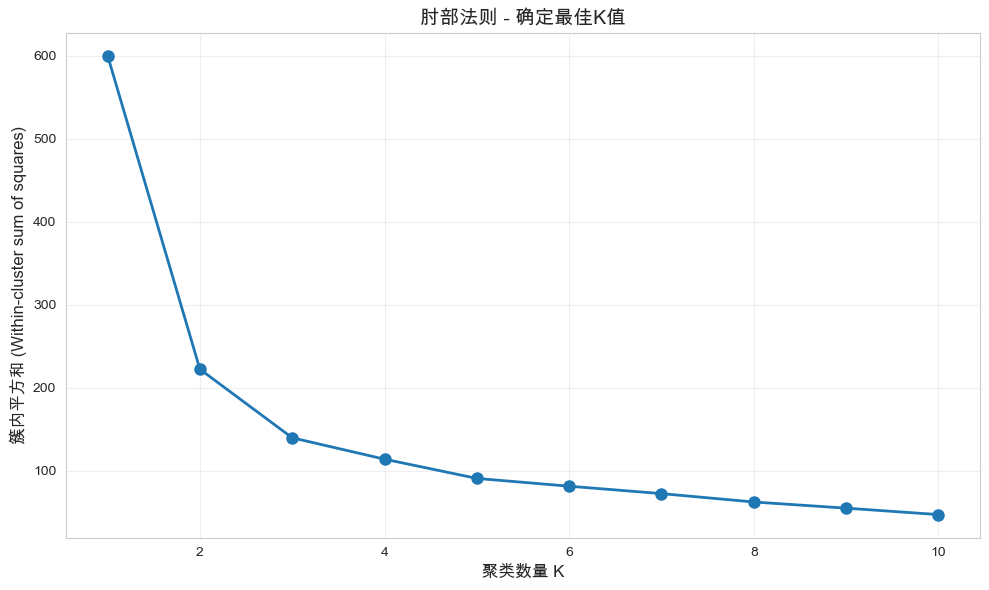

观察图中的'肘部'来确定最佳K值


In [7]:
# 肘部法则 (Elbow Method) - 确定最佳K值
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker='o', linewidth=2, markersize=8)
plt.xlabel('聚类数量 K', fontsize=12)
plt.ylabel('簇内平方和 (Within-cluster sum of squares)', fontsize=12)
plt.title('肘部法则 - 确定最佳K值', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("观察图中的'肘部'来确定最佳K值")

## 层次聚类 (Hierarchical Clustering)

### 什么是层次聚类?

- K-Means聚类的替代方法，用于识别数据集中的组
- 不需要预先指定聚类数量
- 生成基于树的观察表示，称为树状图 (dendrogram)

### 链接方法:

- **Complete linkage**: 簇间最大距离
- **Single linkage**: 簇间最小距离
- **Average linkage**: 簇间平均距离
- **Ward linkage**: 最小化簇内方差

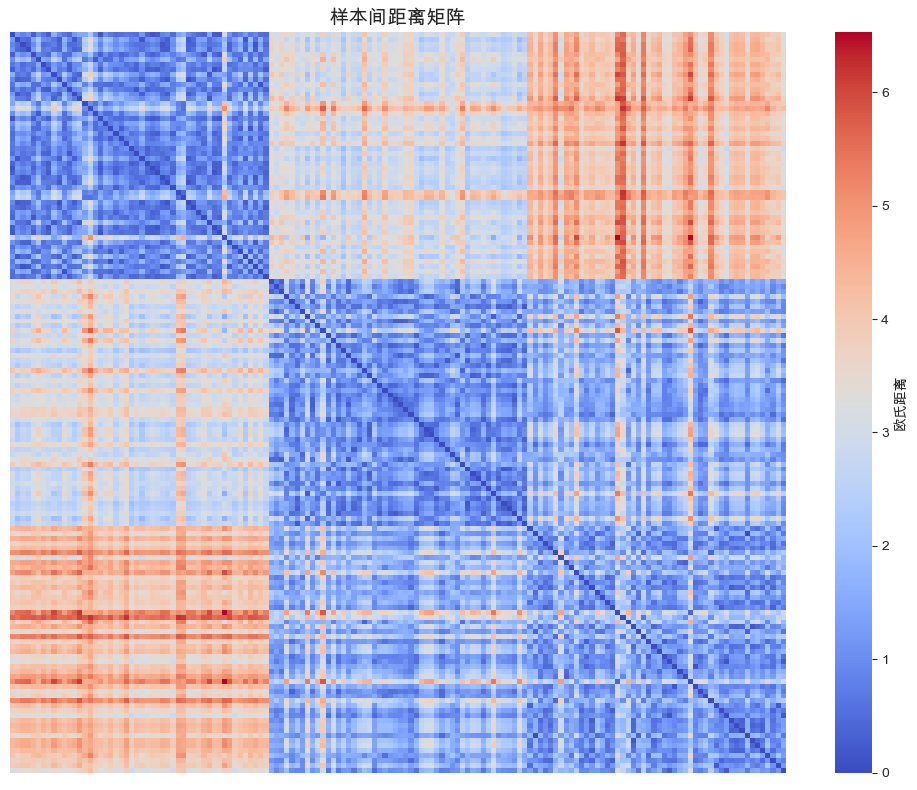

In [8]:
# 计算距离矩阵
from scipy.spatial.distance import pdist, squareform

# 使用欧氏距离
distances = pdist(X_scaled, metric='euclidean')
distance_matrix = squareform(distances)

# 可视化距离矩阵
plt.figure(figsize=(10, 8))
sns.heatmap(distance_matrix, cmap='coolwarm', 
            xticklabels=False, yticklabels=False,
            cbar_kws={'label': '欧氏距离'})
plt.title('样本间距离矩阵', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

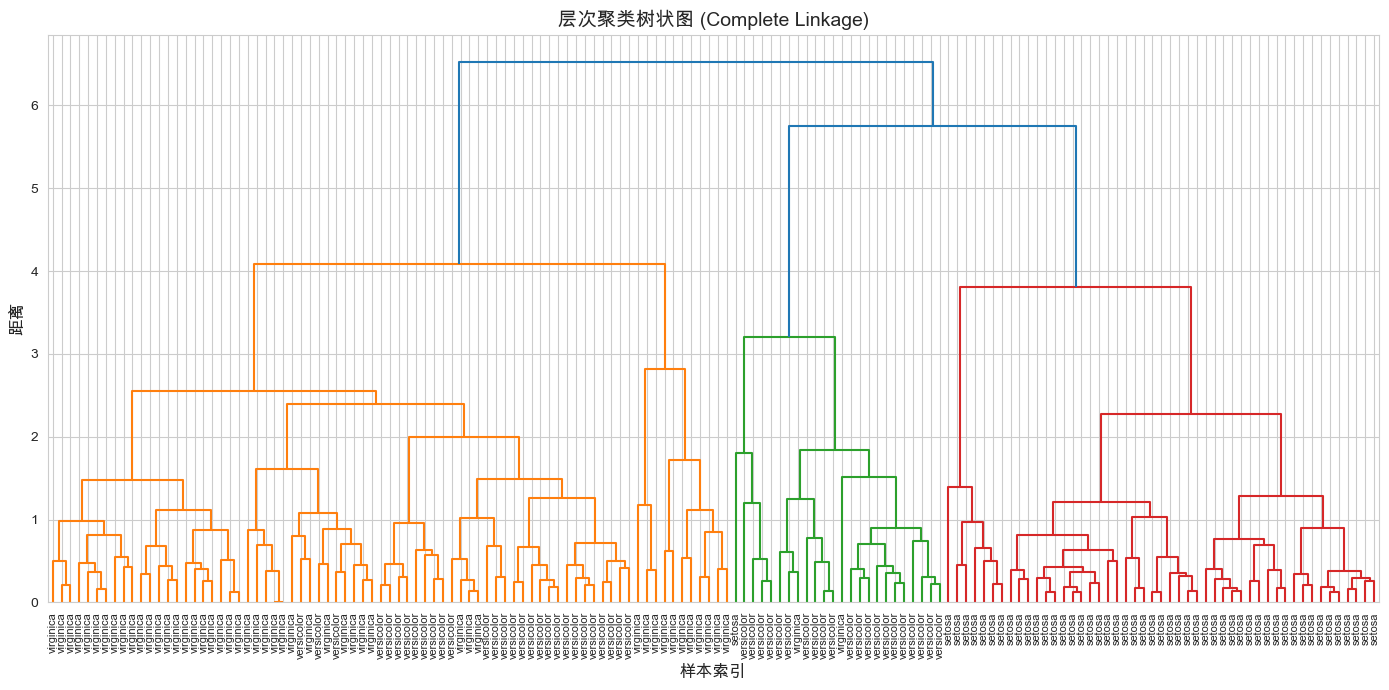

In [9]:
# 执行层次聚类
from scipy.cluster.hierarchy import dendrogram, linkage

# 使用complete linkage
linkage_matrix = linkage(X_scaled, method='complete', metric='euclidean')

# 绘制树状图
plt.figure(figsize=(14, 7))
dendrogram(linkage_matrix, 
           labels=iris.target_names[y],
           leaf_font_size=8)
plt.xlabel('样本索引', fontsize=12)
plt.ylabel('距离', fontsize=12)
plt.title('层次聚类树状图 (Complete Linkage)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 批次效应 (Batch Effect)

### 为什么批次效应是一个问题?

- 技术变异可能掩盖生物信号
- 不同批次的样本可能表现出系统性差异
- 需要在下游分析之前进行校正

### 批次效应去除方法:

在Python中，可以使用以下方法:
- **Combat** (通过rpy2调用R的sva包)
- **Harmony** (scanpy.external.pp.harmony_integrate)
- **其他方法**: 如线性模型回归等

注意: 实际的批次效应去除通常需要使用专门的包，这里展示概念。

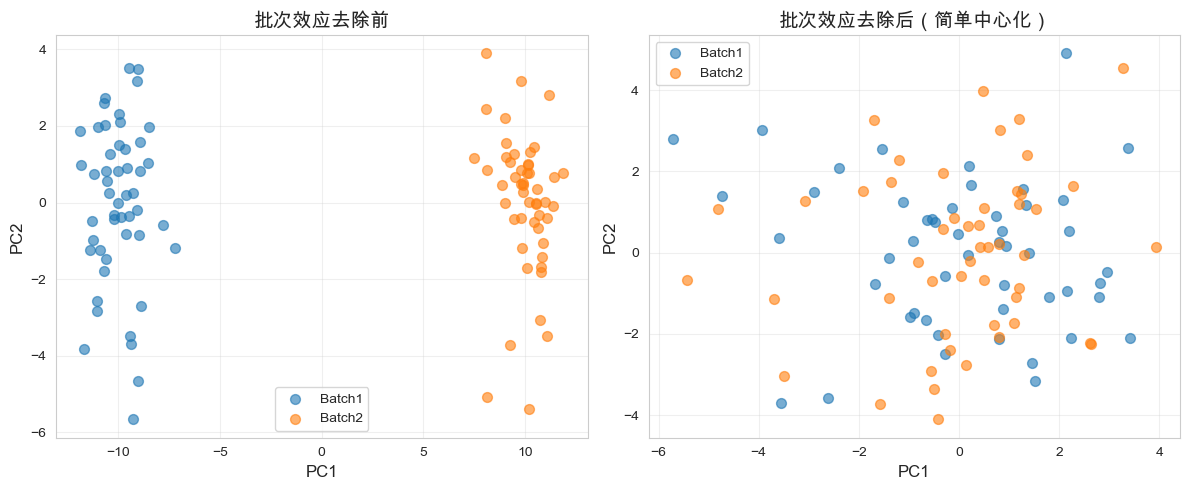

注意：实际分析中应使用Combat或其他专业方法进行批次效应校正


In [10]:
# 模拟批次效应示例
np.random.seed(42)

# 创建模拟数据：两个批次
n_samples_per_batch = 50
n_features = 100

# 批次1
batch1 = np.random.randn(n_samples_per_batch, n_features)
# 批次2 - 添加系统性偏移（批次效应）
batch2 = np.random.randn(n_samples_per_batch, n_features) + 2

# 合并数据
data_with_batch = np.vstack([batch1, batch2])
batch_labels = np.array(['Batch1'] * n_samples_per_batch + ['Batch2'] * n_samples_per_batch)

# PCA可视化批次效应
pca_batch = PCA(n_components=2)
data_pca = pca_batch.fit_transform(data_with_batch)

plt.figure(figsize=(12, 5))

# 批次效应前
plt.subplot(1, 2, 1)
for batch in ['Batch1', 'Batch2']:
    mask = batch_labels == batch
    plt.scatter(data_pca[mask, 0], data_pca[mask, 1], 
               label=batch, alpha=0.6, s=50)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('批次效应去除前', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 简单的批次效应去除：中心化每个批次
data_corrected = data_with_batch.copy()
for batch in ['Batch1', 'Batch2']:
    mask = batch_labels == batch
    data_corrected[mask] = data_with_batch[mask] - data_with_batch[mask].mean(axis=0)

data_corrected_pca = pca_batch.fit_transform(data_corrected)

# 批次效应后
plt.subplot(1, 2, 2)
for batch in ['Batch1', 'Batch2']:
    mask = batch_labels == batch
    plt.scatter(data_corrected_pca[mask, 0], data_corrected_pca[mask, 1], 
               label=batch, alpha=0.6, s=50)
plt.xlabel('PC1', fontsize=12)
plt.ylabel('PC2', fontsize=12)
plt.title('批次效应去除后（简单中心化）', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("注意：实际分析中应使用Combat或其他专业方法进行批次效应校正")

## DESeq2差异表达分析

### 什么是DESeq2?

- RNA-seq数据的差异表达分析工具
- 基于负二项分布模型
- 可以处理小样本量

### Python替代方案:

1. **PyDESeq2**: Python实现的DESeq2
2. **rpy2**: 调用R的DESeq2包
3. **limma-voom**: 通过rpy2调用

这里我们展示概念性的差异表达分析。

In [11]:
# 模拟差异表达分析
# 创建模拟的基因表达数据
np.random.seed(42)

n_genes = 1000
n_samples_per_condition = 10

# 对照组
control = np.random.negative_binomial(10, 0.5, size=(n_genes, n_samples_per_condition))

# 处理组 - 前100个基因上调
treatment = control.copy()
treatment[:100, :] = treatment[:100, :] * 3  # 3倍上调

# 合并数据
expression_data = np.hstack([control, treatment])
gene_names = [f'Gene_{i}' for i in range(n_genes)]
sample_names = [f'Control_{i}' for i in range(n_samples_per_condition)] + \
               [f'Treatment_{i}' for i in range(n_samples_per_condition)]

# 创建DataFrame
expr_df = pd.DataFrame(expression_data, index=gene_names, columns=sample_names)

print("表达数据形状:", expr_df.shape)
print("\n前5个基因，前5个样本:")
print(expr_df.iloc[:5, :5])

表达数据形状: (1000, 20)

前5个基因，前5个样本:
        Control_0  Control_1  Control_2  Control_3  Control_4
Gene_0         12          7          8          5          6
Gene_1          6          9          5         17         15
Gene_2          4          6         13         10         11
Gene_3         17         13          5          2          5
Gene_4          3          6         12          5         13


In [12]:
# 简单的差异表达分析（使用t检验作为示例）
from scipy.stats import ttest_ind

results = []
for gene in gene_names:
    control_expr = expr_df.loc[gene, [c for c in sample_names if 'Control' in c]]
    treatment_expr = expr_df.loc[gene, [c for c in sample_names if 'Treatment' in c]]
    
    # t检验
    t_stat, p_value = ttest_ind(control_expr, treatment_expr)
    
    # 计算fold change
    mean_control = control_expr.mean()
    mean_treatment = treatment_expr.mean()
    log2fc = np.log2((mean_treatment + 1) / (mean_control + 1))
    
    results.append({
        'gene': gene,
        'log2FoldChange': log2fc,
        'pvalue': p_value,
        'mean_control': mean_control,
        'mean_treatment': mean_treatment
    })

results_df = pd.DataFrame(results)

# FDR校正 (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
results_df['padj'] = multipletests(results_df['pvalue'], method='fdr_bh')[1]

# 筛选显著差异基因
significant_genes = results_df[(results_df['padj'] < 0.05) & (abs(results_df['log2FoldChange']) > 1)]

print(f"显著差异基因数量: {len(significant_genes)}")
print("\n前10个显著差异基因:")
print(significant_genes.head(10))

显著差异基因数量: 92

前10个显著差异基因:
       gene  log2FoldChange        pvalue  mean_control  mean_treatment  \
0    Gene_0        1.483322  4.971419e-05           8.8            26.4   
1    Gene_1        1.507170  3.979138e-04          11.7            35.1   
2    Gene_2        1.491248  1.482866e-05           9.6            28.8   
4    Gene_4        1.498027  5.344208e-04          10.4            31.2   
5    Gene_5        1.484386  1.186754e-03           8.9            26.7   
6    Gene_6        1.483322  2.065549e-05           8.8            26.4   
7    Gene_7        1.478834  2.255869e-04           8.4            25.2   
8    Gene_8        1.497234  4.062777e-07          10.3            30.9   
9    Gene_9        1.508409  1.721803e-03          11.9            35.7   
11  Gene_11        1.478834  1.311933e-04           8.4            25.2   

        padj  
0   0.001604  
1   0.006217  
2   0.000620  
4   0.007448  
5   0.015412  
6   0.000765  
7   0.004256  
8   0.000066  
9   0.020498 

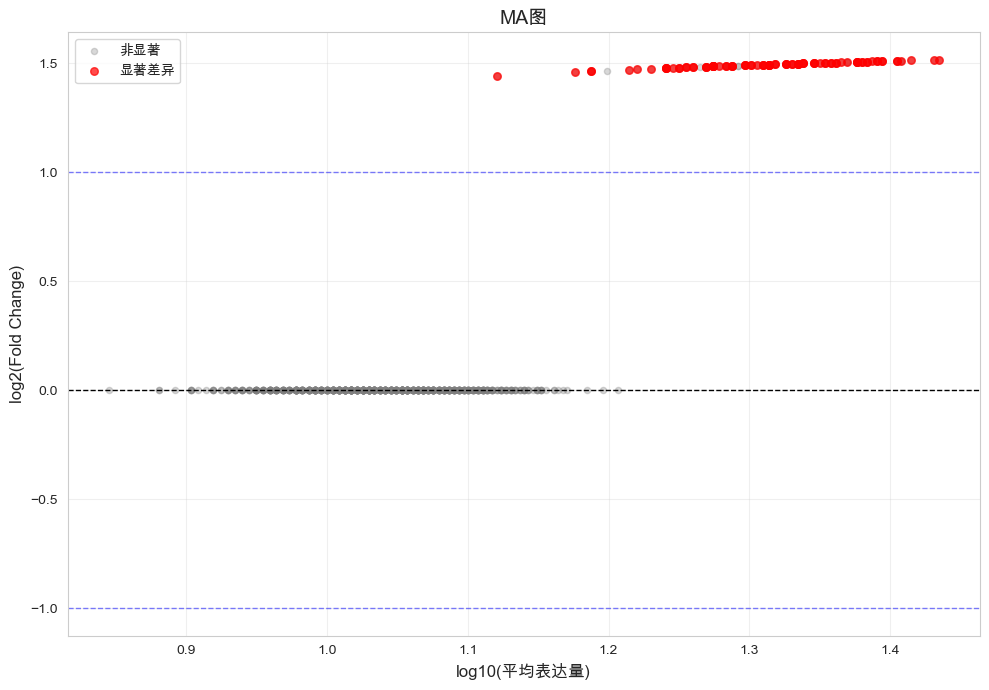

In [13]:
# MA图 (Mean-Average plot)
plt.figure(figsize=(10, 7))

# 计算平均表达
results_df['baseMean'] = (results_df['mean_control'] + results_df['mean_treatment']) / 2

# 绘制所有基因
plt.scatter(np.log10(results_df['baseMean'] + 1), 
           results_df['log2FoldChange'],
           alpha=0.3, s=20, c='gray', label='非显著')

# 绘制显著差异基因
sig_idx = (results_df['padj'] < 0.05) & (abs(results_df['log2FoldChange']) > 1)
plt.scatter(np.log10(results_df.loc[sig_idx, 'baseMean'] + 1),
           results_df.loc[sig_idx, 'log2FoldChange'],
           alpha=0.7, s=30, c='red', label='显著差异')

plt.xlabel('log10(平均表达量)', fontsize=12)
plt.ylabel('log2(Fold Change)', fontsize=12)
plt.title('MA图', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axhline(y=1, color='blue', linestyle='--', linewidth=1, alpha=0.5)
plt.axhline(y=-1, color='blue', linestyle='--', linewidth=1, alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

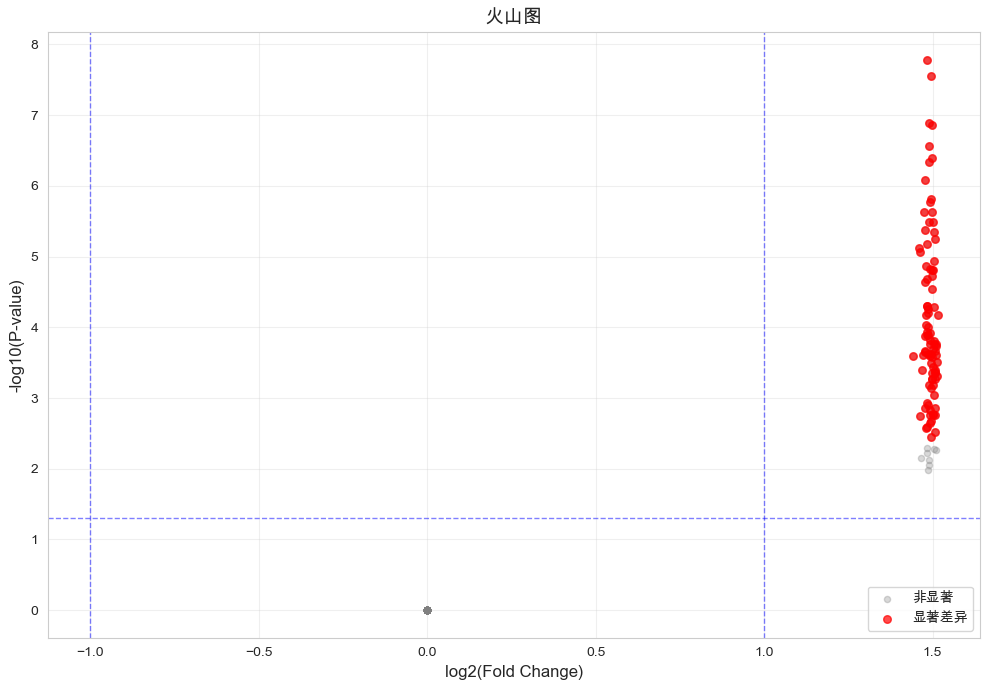

In [14]:
# 火山图 (Volcano Plot)
plt.figure(figsize=(10, 7))

# 绘制所有基因
plt.scatter(results_df['log2FoldChange'], 
           -np.log10(results_df['pvalue']),
           alpha=0.3, s=20, c='gray', label='非显著')

# 绘制显著差异基因
plt.scatter(results_df.loc[sig_idx, 'log2FoldChange'],
           -np.log10(results_df.loc[sig_idx, 'pvalue']),
           alpha=0.7, s=30, c='red', label='显著差异')

plt.xlabel('log2(Fold Change)', fontsize=12)
plt.ylabel('-log10(P-value)', fontsize=12)
plt.title('火山图', fontsize=14, fontweight='bold')
plt.axvline(x=1, color='blue', linestyle='--', linewidth=1, alpha=0.5)
plt.axvline(x=-1, color='blue', linestyle='--', linewidth=1, alpha=0.5)
plt.axhline(y=-np.log10(0.05), color='blue', linestyle='--', linewidth=1, alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## GSEA (基因集富集分析)

### DAVID vs. GSEA

- **DAVID**: 获取选定的差异表达基因列表，查看某些基因集中的基因是否通过计数过度代表
- **GSEA**: 获取所有基因并使用测试统计量（例如t值）。不需要设置阈值

### GSEA分析步骤:

1. 对所有基因进行排序
2. 识别基因集中所有成员在排序数据集中的秩位置
3. 计算富集分数(ES)，表示观察到的排名与假设随机排名分布之间的差异

### Python中的GSEA:

- **gseapy**: Python的GSEA实现
- 可以使用MSigDB数据库
- 支持预排序GSEA分析

基因排序（前10个上调基因）:
gene
Gene_76    1.515085
Gene_25    1.514573
Gene_29    1.511899
Gene_45    1.510772
Gene_55    1.510772
Gene_65    1.510195
Gene_77    1.510195
Gene_16    1.508409
Gene_9     1.508409
Gene_30    1.507795
Name: log2FoldChange, dtype: float64

基因排序（前10个下调基因）:
gene
Gene_397    0.0
Gene_398    0.0
Gene_399    0.0
Gene_400    0.0
Gene_401    0.0
Gene_402    0.0
Gene_403    0.0
Gene_404    0.0
Gene_405    0.0
Gene_999    0.0
Name: log2FoldChange, dtype: float64


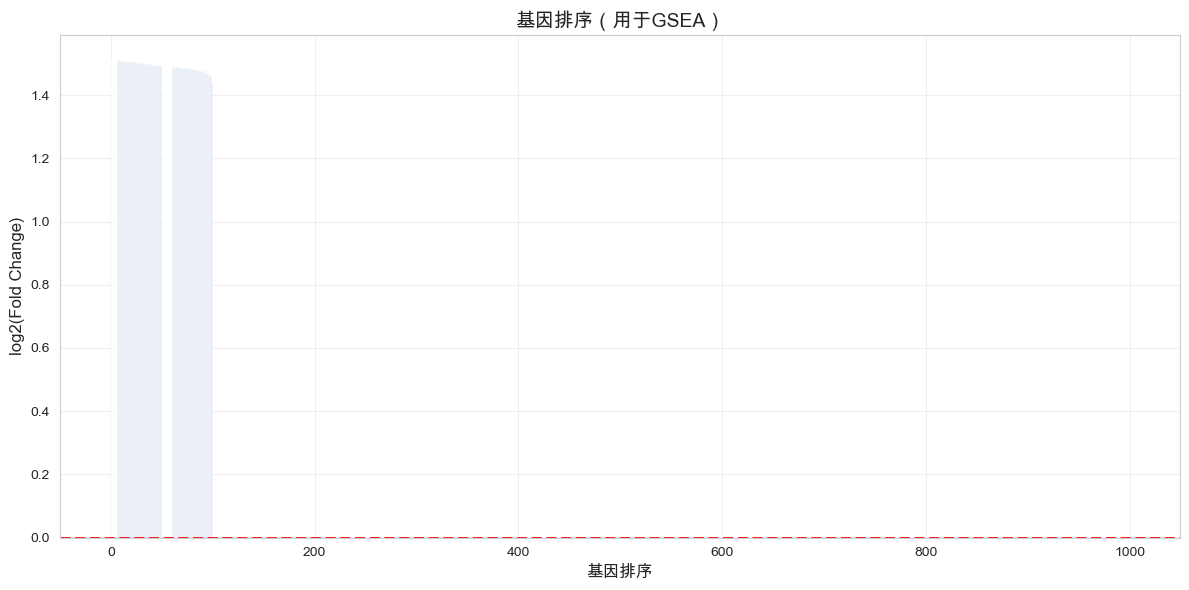

In [15]:
# 创建基因排序列表
# 按log2FoldChange排序
gene_ranks = results_df.set_index('gene')['log2FoldChange'].sort_values(ascending=False)

print("基因排序（前10个上调基因）:")
print(gene_ranks.head(10))

print("\n基因排序（前10个下调基因）:")
print(gene_ranks.tail(10))

# 可视化排序
plt.figure(figsize=(12, 6))
plt.bar(range(len(gene_ranks)), gene_ranks.values, color='steelblue', alpha=0.7)
plt.xlabel('基因排序', fontsize=12)
plt.ylabel('log2(Fold Change)', fontsize=12)
plt.title('基因排序（用于GSEA）', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 注意:

对于实际的GSEA分析，建议使用:

```python
# 安装gseapy
# pip install gseapy

import gseapy as gp

# 运行预排序GSEA
gsea_results = gp.prerank(
    rnk=gene_ranks,
    gene_sets='KEGG_2019_Human',  # 或其他基因集
    processes=4,
    permutation_num=1000,
    outdir='gsea_results',
    format='png',
    seed=42
)
```

这需要互联网连接来下载基因集数据库。

---

## 总结

在本实验中，我们学习了:

1. **PCA分析**: 降维和数据可视化
2. **K-Means聚类**: 无监督学习方法
3. **层次聚类**: 树状图构建和解释
4. **批次效应**: 识别和校正技术变异
5. **差异表达分析**: 识别显著差异基因
6. **GSEA**: 基因集富集分析的概念

### Python工具总结:

- `sklearn`: PCA和聚类
- `scipy`: 层次聚类和统计检验
- `pandas`: 数据操作
- `matplotlib/seaborn`: 可视化
- `pydeseq2`或`rpy2`: 差异表达分析
- `gseapy`: GSEA分析

### 进一步学习:

- Scanpy: 单细胞RNA-seq分析
- PyDESeq2: Python原生的DESeq2实现
- GSEApy: 完整的GSEA分析工具

---